# UrbanFusion Tutorial: Multimodal Encoding for Downstream Tasks

This notebook demonstrates how to:

1. **Generate a synthetic dataset** of 16 random (latitude, longitude) points in London, along with smoothly varying synthetic labels (e.g., mimicking population density).
2. **Download and preprocess multimodal inputs**  
   - Street-view imagery  
   - Remote sensing imagery  
   - Cartographic basemaps  
   - Points of interest (POIs)  
3. **Download and apply the pretrained UrbanFusion model** to generate high-dimensional representations for each location using any chosen subset of modalities. We will examine how the model can flexibly handle both raw input modalities and precomputed features.
4. **Leverage these embeddings in a downstream regression task**, where a linear regression model is trained and tuned to predict the synthetic labels, illustrating how UrbanFusion representations can support spatial learning tasks.  


## 0) Setup

Import the required libraries.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
import contextily as cx
import contextily.tile as _ct
from rasterio.windows import Window
from rasterio.transform import from_bounds, rowcol
from rasterio.warp import calculate_default_transform, reproject, Resampling
import planetary_computer
import pystac_client
import stackstac
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import BallTree
import torch
import torchvision.transforms as T
from torchvision import transforms
from transformers import AutoTokenizer, AutoImageProcessor
import rioxarray
import requests
from io import BytesIO
from PIL import Image
from tqdm import tqdm
from typing import Any, Dict, List, Tuple
import overpy
import warnings
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", module="sklearn")
warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# UrbanFusion
from huggingface_hub import hf_hub_download
from srl.multi_modal_encoder.load import get_urbanfusion

c:\Users\domin\Code_Projects\MSc_Geomatics\Master_thesis\SpatialFoundationModel\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 1) Sample 16 Random Locations in London

We'll define a small bounding box roughly around the city center of London and sample 16 random points uniformly in latitude/longitude.

In [2]:
# Reproducibility
rng = np.random.default_rng(5) #1999

# A simple bounding box around central London (approx.)
# lat_min/max, lon_min/max (WGS84, EPSG:4326)
lat_min, lat_max = 51.495, 51.520
lon_min, lon_max = -0.15, -0.07

# Generate random coordinates within the bounding box
n_points = 16
lats = rng.uniform(lat_min, lat_max, n_points)
lons = rng.uniform(lon_min, lon_max, n_points)

# Create GeoDataFrame
df = pd.DataFrame({'lat': lats, 'lon': lons})
gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['lon'], df['lat'])], crs="EPSG:4326")
gdf.head()


,lat,lon,geometry
0,51.515125,-0.118608,POINT (-0.11861 51.51513)
1,51.515199,-0.110558,POINT (-0.11056 51.5152)
2,51.507883,-0.095865,POINT (-0.09586 51.50788)
3,51.502145,-0.145136,POINT (-0.14514 51.50215)
4,51.496348,-0.105552,POINT (-0.10555 51.49635)


## 2) Download and Preprocess Street-View Images

We collect street-view imagery around the 16 predefined locations to provide additional contextual input for UrbanFusion. In our study, we relied on the Place Pulse 2.0 dataset as the source of georeferenced street-view images, but alternative providers such as the Google Maps API or Mapillary can also be used. Please note that data quality may vary depending on the provider, and manual verification may be required.

For this tutorial, we use **Mapillary**. To follow along, create a free account at [mapillary.com](https://www.mapillary.com/app/) and generate an API access token, which will allow you to download imagery through the Mapillary API.


Fetching Mapillary: 100%|██████████| 16/16 [00:14<00:00,  1.14it/s]

Images found: 16 / 16


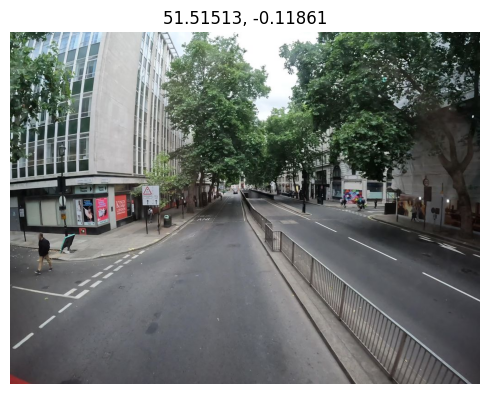

SV tensor shape: (16, 3, 224, 224)
Dtype, min, max: torch.float32 -2.1179039478302 2.640000104904175


In [ ]:
# Put your token here:
TOKEN = "MLY|xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  # <-- put your token here
TOKEN = "MLY|24656502810653451|3a716d6baa0b57067a0fa515c50faa79"
# Mapillary API endpoint
MAPILLARY_URL = "https://graph.mapillary.com/images"


def deg_buffer_m(lat_deg: float, m: float) -> tuple:
    """
    Convert a buffer distance in meters to a latitude/longitude degree buffer.

    Parameters
    ----------
    lat_deg : float
        Latitude in degrees.
    m : float
        Buffer distance in meters.

    Returns
    -------
    tuple
        (dlat, dlon) where dlat is the latitude degree buffer and dlon is the longitude degree buffer.
    """
    # Meters -> ~degrees at this latitude
    # 1 deg lat ~ 111_320 m; 1 deg lon ~ 111_320 * cos(lat) m
    dlat = m / 111_320.0
    dlon = m / (111_320.0 * max(0.1, math.cos(math.radians(lat_deg))))
    return dlat, dlon


def fetch_mapillary_nearest_thumbs(
    gdf: gpd.GeoDataFrame,
    token: str,
    lat_col: str = "lat",
    lon_col: str = "lon",
    radius_m: int = 200,
    size_field: str = "thumb_1024_url",
    timeout_s: int = 10,
    max_tries: int = 3,
) -> gpd.GeoDataFrame:
    """
    Fetch Mapillary thumbnails for the nearest images to the given GeoDataFrame.

    Parameters
    ----------
    gdf : gpd.GeoDataFrame
        GeoDataFrame containing the points to search around.
    token : str
        Mapillary API token.
    lat_col : str
        Name of the column containing latitude values.
    lon_col : str
        Name of the column containing longitude values.
    radius_m : int
        Search radius in meters.
    size_field : str
        Size of the thumbnail to fetch.
    timeout_s : int
        Request timeout in seconds.
    max_tries : int
        Maximum number of attempts to fetch images,
        each time expanding the search radius.

    Returns
    -------
    gpd.GeoDataFrame
        GeoDataFrame containing the fetched Mapillary thumbnails.
    """
    assert size_field in ("thumb_256_url", "thumb_1024_url", "thumb_2048_url")

    # Prepare session
    s = requests.Session()
    s.headers.update({"Authorization": f"OAuth {token}"})

    # Iterate over coordinates
    out_rows = []
    for _, row in tqdm(gdf.iterrows(), total=len(gdf), desc="Fetching Mapillary"):
        lat, lon = float(row[lat_col]), float(row[lon_col])
        image_id = thumb_url = None
        pil_img = None

        # Try growing boxes: r, 2r, 3r...
        found = False
        for k in range(1, max_tries + 1):
            dlat, dlon = deg_buffer_m(lat, radius_m * k)
            bbox = f"{lon-dlon},{lat-dlat},{lon+dlon},{lat+dlat}"  # Left,south,right,north

            params = {
                "fields": f"id,{size_field},geometry",
                "bbox": bbox,
                "limit": 50,
                "image_type": "photo",
            }
            try:
                r = s.get(MAPILLARY_URL, params=params, timeout=timeout_s)
                r.raise_for_status()
                data = r.json().get("data", [])

                # Pick nearest by haversine
                def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
                    """
                    Calculate the Haversine distance between two points on the Earth.
                    """
                    R=6371000
                    a=math.radians(lat2-lat1); b=math.radians(lon2-lon1)
                    x=math.sin(a/2)**2 + math.cos(math.radians(lat1))*math.cos(math.radians(lat2))*math.sin(b/2)**2
                    return 2*R*math.asin(math.sqrt(x))

                if data:
                    data.sort(key=lambda d: haversine(
                        lat, lon,
                        d.get("geometry", {}).get("coordinates", [None, None])[1],
                        d.get("geometry", {}).get("coordinates", [None, None])[0],
                    ))
                    top = data[0]
                    image_id = top.get("id")
                    thumb_url = top.get(size_field)
                    found = True

                    # Download image
                    if thumb_url:
                        try:
                            img_resp = s.get(thumb_url, timeout=timeout_s)
                            img_resp.raise_for_status()
                            pil_img = Image.open(BytesIO(img_resp.content)).convert("RGB")
                        except Exception as e:
                            print(f"Thumbnail fetch error @ {lat:.5f},{lon:.5f}: {e}")
                    break
            except Exception as e:
                print(f"API error @ {lat:.5f},{lon:.5f} (try {k}): {e}")
                # fall through to retry with larger bbox

        if not found:
            # helpful debug to see what the API actually returned last
            try:
                print("Last URL:", r.url)
                print("Last payload keys:", list(r.json().keys()))
            except Exception:
                pass

        out_row = row.copy()
        out_row["image_id"] = image_id
        out_row["thumb_url"] = thumb_url
        out_row["pil"] = pil_img
        out_rows.append(out_row)

    return gpd.GeoDataFrame(out_rows, crs=gdf.crs)

# Fetch street-view images for the generated points
gdf_with_imgs = fetch_mapillary_nearest_thumbs(gdf, TOKEN, radius_m=50, size_field="thumb_1024_url")
num_found = gdf_with_imgs["pil"].notna().sum()
print(f"Images found: {num_found} / {len(gdf_with_imgs)}")

# Plot example image
first_row = gdf_with_imgs[gdf_with_imgs["pil"].notna()].head(1)
if len(first_row) == 0:
    raise RuntimeError("No images downloaded; can't plot or preprocess.")
pil_img = first_row.iloc[0]["pil"]
lat0 = first_row.iloc[0]["lat"]
lon0 = first_row.iloc[0]["lon"]

plt.figure(figsize=(5, 5))
plt.imshow(pil_img)
plt.axis("off")
plt.title(f"{lat0:.5f}, {lon0:.5f}")
plt.tight_layout()
plt.show()

# Preprocess images into a tensor (for UrbanFusion)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.PILToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225),
    ),
])
valid = gdf_with_imgs[gdf_with_imgs["pil"].notna()].copy()
tensors = []
image_ids = []
for i, r in valid.iterrows():
    try:
        t = transform(r["pil"])  # (3,224,224)
        tensors.append(t)
        image_ids.append(r.get("image_id", None))
    except Exception as e:
        print(f"Preprocess failed for row {i}: {e}")

if len(tensors) == 0:
    raise RuntimeError("No tensors produced; check preprocessing pipeline.")

sv_tensors = torch.stack(tensors, dim=0)  # (N,3,224,224)
print("SV tensor shape:", tuple(sv_tensors.shape))
print("Dtype, min, max:", sv_tensors.dtype, float(sv_tensors.min()), float(sv_tensors.max()))


## 3) Download and Preprocess Sentinel-2 Satellite Images

We extract Sentinel-2 image patches around the 16 locations defined above, providing additional contextual input for UrbanFusion.  

⚠️ Note: for larger-scale datasets it is more efficient to download full Sentinel-2 tiles covering the city and then generate patches locally, rather than requesting each patch individually from the API. An implementation of this approach is provided in:  
`scripts/preprocessing/Place_pulse_2/download_sentinel2_fast2.py`


✅ Retrieved 16 in-memory patches (each: 12×256×256, uint16)


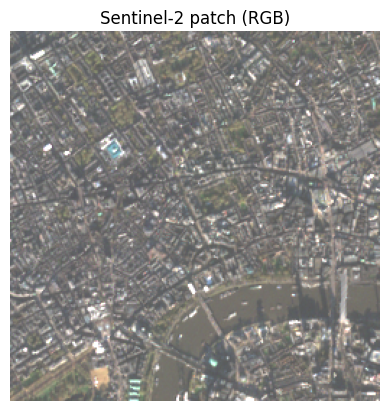

Torch batch shape: (16, 13, 224, 224)


In [ ]:
# Initialize STAC catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/",
    modifier=planetary_computer.sign_inplace,
)

# Configuration for Sentinel-2
BAND_LIST = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]  # full 12 bands
DATE_MIN, DATE_MAX = "2024-01-01", "2024-12-31"
PATCH_SIZE = 256
HALF = PATCH_SIZE // 2

# Get patches for each location
patches = [] 
for i, row in gdf.iterrows():
    lon, lat = row.geometry.x, row.geometry.y

    # Lowest-cloud scene in range
    search = catalog.search(
        intersects={"type": "Point", "coordinates": [lon, lat]},
        collections=["sentinel-2-l2a"],
        datetime=f"{DATE_MIN}/{DATE_MAX}",
        sortby=[{"field": "eo:cloud_cover", "direction": "asc"}],
        max_items=1,
        limit=1,
    )
    item = next(search.items(), None)
    if item is None:
        print(f"[{i}] No scene found → skipped")
        continue

    # Build 12-band stack, EPSG:4326
    stack = stackstac.stack(item, assets=BAND_LIST, epsg=4326, chunksize=PATCH_SIZE)

    # Compute pixel window centered at the point
    transform = stack.rio.transform()
    col_f, row_f = ~transform * (lon, lat)
    col, row = int(col_f), int(row_f)
    window = Window(col - HALF, row - HALF, PATCH_SIZE, PATCH_SIZE)

    # Bounds check to avoid partial edges
    H, W = stack.sizes["y"], stack.sizes["x"]
    col0 = max(0, window.col_off)
    row0 = max(0, window.row_off)
    col1 = min(W, col0 + window.width)
    row1 = min(H, row0 + window.height)
    width, height = int(col1 - col0), int(row1 - row0)
    if width != PATCH_SIZE or height != PATCH_SIZE:
        print(f"[{i}] Patch near edge (got {height}x{width}) → skipped")
        continue

    # Extract and load into memory as uint16 (drop time)
    patch3d = (
        stack.isel(time=0)
             .rio.isel_window(Window(col0, row0, width, height))
             .astype("uint16")
             .load()
    )
    patches.append(patch3d)

print(f"✅ Retrieved {len(patches)} in-memory patches (each: 12×{PATCH_SIZE}×{PATCH_SIZE}, uint16)")

# Plot (RGB only)
rgb = np.stack(
    [patches[0].sel(band="B04").values,  # R
        patches[0].sel(band="B03").values,  # G
        patches[0].sel(band="B02").values], # B
    axis=-1
)
rgb = np.clip(rgb / 3000.0, 0, 1)
plt.imshow(rgb)
plt.title("Sentinel-2 patch (RGB)")
plt.axis("off")
plt.show()

# Torch pipeline: scale/insert B10/CenterCrop(224) -----
transform_sentinel2 = T.Compose([T.CenterCrop(224)])


def patch_to_tensor(patch3d, transform: callable=transform_sentinel2) -> torch.FloatTensor:
    """
    Convert xarray patch (12 bands) to torch tensor with:
      - float32 reflectance scaling (/10000)
      - inserted dummy B10 (zeros) between B09 and B11  -> 13 channels
      - transform (e.g., CenterCrop(224))
    
    Parameters
    ----------
    patch3d : rioxarray.DataArray
        The 3D patch to convert.
    transform : callable
        A transformation function to apply (e.g., CenterCrop).

    Returns
    -------
    torch.FloatTensor
        Returns: FloatTensor (13, H', W')
    """
    arr = patch3d.values.astype(np.float32) / 10000.0  # (12, H, W)
    B10 = np.zeros((1, arr.shape[1], arr.shape[2]), dtype=np.float32)
    # Add zero channel to support backbone
    arr = np.concatenate([arr[:10], B10, arr[10:]], axis=0)   # (13, H, W)
    ten = torch.from_numpy(arr)  # float32
    return transform(ten) if transform is not None else ten

batch_tensor = None
tensors = [patch_to_tensor(p) for p in patches]  # list of (13, 224, 224)
rs_tensor = torch.stack(tensors, dim=0)  # (N, 13, 224, 224)
print("Torch batch shape:", tuple(rs_tensor.shape))


## 4) Download and Preprocess OpenStreetMap (OSM) Basemaps

We extract OpenStreetMap (OSM) basemap patches centered on the 16 locations defined above to provide additional spatial context for UrbanFusion. To capture multiscale patterns, we generate patches at three buffer extents (150 m, 300 m, 600 m) using zoom levels 17, 16, and 15 in the same order.


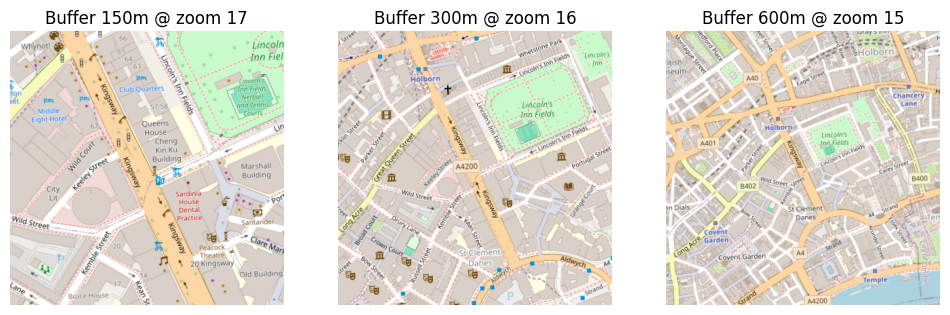

Tensor shape for first point: (9, 224, 224)
OSM batch shape: (16, 9, 224, 224)


In [5]:
# Set user agent
_ct.USER_AGENT = "UrbanFusion/0.1 (+contact@example.com)"

# Configuration
BUFFER_SIZES = [150, 300, 600]  # in meters
ZOOM_LEVELS  = [17, 16, 15]
PROVIDER = cx.providers.OpenStreetMap.Mapnik

# Preprocessing for OSM-MAE backbone
processor = AutoImageProcessor.from_pretrained("facebook/vit-mae-base", use_fast=True)

# Local UTM for London to make buffering truly meters
LOCAL_UTM_CRS = "EPSG:32630"  # WGS84 / UTM zone 30N (London)
MARGIN_M = 200  # download a bit more than needed


def fetch_osm_patch(pt_lonlat: tuple, buffer_m: int, zoom: int, margin_m: int = MARGIN_M) -> Image.Image:
    """
    Fetch a square patch of OSM imagery centered at (lon, lat), with a buffer in meters.
    Downloads a slightly larger area in Web Mercator, reprojects to local UTM, then crops
    the exact UTM square.

    Parameters
    ----------
    pt_lonlat : tuple[float, float]
        (longitude, latitude) in EPSG:4326.
    buffer_m : int
        Half-size of the square patch in meters (e.g., 600 -> 1200 m square).
    zoom : int
        OSM/Web Mercator zoom level for backing tiles.
    margin_m : int
        Extra meters added around the requested patch to avoid edge artifacts.

    Returns
    -------
    PIL.Image.Image
        RGB image of the requested UTM-square patch.
    """
    # Center point in local UTM
    pt_utm = gpd.GeoSeries([Point(pt_lonlat)], crs="EPSG:4326").to_crs(LOCAL_UTM_CRS).iloc[0]
    x, y = pt_utm.x, pt_utm.y

    # Desired UTM bbox (exact output crop)
    des_minx, des_miny, des_maxx, des_maxy = x - buffer_m, y - buffer_m, x + buffer_m, y + buffer_m

    # Expanded UTM bbox to fetch (avoid edge artifacts)
    exp_utm = box(
        x - (buffer_m + margin_m),
        y - (buffer_m + margin_m),
        x + (buffer_m + margin_m),
        y + (buffer_m + margin_m),
    )

    # Fetch bigger image in Web Mercator
    exp_wm = gpd.GeoSeries([exp_utm], crs=LOCAL_UTM_CRS).to_crs(3857).iloc[0]
    req_minx, req_miny, req_maxx, req_maxy = exp_wm.bounds

    img, extent = cx.bounds2img(req_minx, req_miny, req_maxx, req_maxy,
                                zoom=zoom, source=PROVIDER, ll=False)
    H, W = img.shape[:2]
    left, right, bottom, top = extent
    src_transform = from_bounds(left, bottom, right, top, W, H)

    # Reproject fetched image to local UTM
    dst_crs = LOCAL_UTM_CRS
    dst_transform, dst_width, dst_height = calculate_default_transform(
        "EPSG:3857", dst_crs, W, H, left, bottom, right, top
    )

    # Ensure 3 bands (drop alpha if present)
    bands_src = img[:, :, :3].transpose(2, 0, 1).astype(np.uint8)  # (3, H, W)
    bands_dst = np.zeros((3, dst_height, dst_width), dtype=np.uint8)

    for i in range(3):
        reproject(
            source=bands_src[i],
            destination=bands_dst[i],
            src_transform=src_transform,
            src_crs="EPSG:3857",
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
        )

    # Crop exact desired UTM bbox from the UTM image
    r0, c0 = rowcol(dst_transform, des_minx, des_maxy, op=np.floor)  # UL corner
    r1, c1 = rowcol(dst_transform, des_maxx, des_miny, op=np.ceil)   # LR corner

    # Clamp to bounds
    r0 = int(max(0, min(dst_height, r0)))
    r1 = int(max(0, min(dst_height, r1)))
    c0 = int(max(0, min(dst_width,  c0)))
    c1 = int(max(0, min(dst_width,  c1)))

    if r1 <= r0 or c1 <= c0:
        raise ValueError("Empty crop — check transforms/bounds.")

    crop = bands_dst[:, r0:r1, c0:c1]  # (3, h, w)

    # Sanity check: should be ~2*buffer_m in meters
    from rasterio.transform import xy
    ulx, uly = xy(dst_transform, r0, c0, offset='ul')
    lrx, lry = xy(dst_transform, r1, c1, offset='lr')

    pil = Image.fromarray(crop.transpose(1, 2, 0), mode="RGB")
    return pil


def osm_tensor_for_point(pt_lonlat: tuple, plot: bool = False) -> torch.FloatTensor:
    """
    Fetch OSM imagery for a point and convert to tensor.

    Parameters
    ----------
    pt_lonlat : tuple
        The (longitude, latitude) of the point to fetch imagery for.
    plot : bool
        Whether to plot the fetched images.

    Returns
    -------
    torch.FloatTensor
        The OSM imagery as a tensor.
    """
    pil_images, tensors = [], []
    for buf_m, z in zip(BUFFER_SIZES, ZOOM_LEVELS):
        pil = fetch_osm_patch(pt_lonlat, buf_m, z)
        pil_images.append(pil)
        pix = processor(images=pil, return_tensors="pt").pixel_values.squeeze(0)  # (3,H,W)
        tensors.append(pix)

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        for j, (ax, im, buf, z) in enumerate(zip(axes, pil_images, BUFFER_SIZES, ZOOM_LEVELS)):
            # print shape of im
            ax.imshow(im)
            ax.set_title(f"Buffer {buf}m @ zoom {z}")
            ax.axis("off")
        plt.show()

    return torch.cat(tensors, dim=0)  # (9, H, W)

# Run for one point and plot
lon, lat = gdf.iloc[0].geometry.x, gdf.iloc[0].geometry.y
tensor_example = osm_tensor_for_point((lon, lat), plot=True)
print("Tensor shape for first point:", tuple(tensor_example.shape))

# Batch for all points
osm_tensors= torch.stack([osm_tensor_for_point((row.geometry.x, row.geometry.y)) for _, row in gdf.iterrows()], dim=0)
print("OSM batch shape:", tuple(osm_tensors.shape))


## 5) Download and Preprocess Points of Interest (POI)

We collect street-view imagery around the 16 predefined locations to provide additional contextual input for UrbanFusion. In our study, we relied on the Place Pulse 2.0 dataset as the source of georeferenced street-view images, but alternative providers such as the Google Maps API or Mapillary can also be used.  

For this tutorial, we use **Mapillary**. To follow along, create a free account at [mapillary.com](https://www.mapillary.com/app/) and generate an API access token, which will allow you to download imagery through the Mapillary API.


In [ ]:
# Configuration
BUFFER_DISTANCE_M = 200  # Consider only POIs within 200m
NUM_NEIGHBORS = 15  # Number of POIs to consider per location

# Overpass tag filters
CUSTOM_FILTER: Dict[str, Any] = {
    "healthcare": True,
    "shop": True,
    "leisure": True,
    "amenity": True,
    "tourism": True,
    "building": ["religious", "transportation"],
    "public_transport": ["station"],
    "theatre": True,
    "cinema": True,
}


def compute_bbox(points: gpd.GeoSeries, buffer_m: float) -> list:
    """
    Compute WGS84 bounding box for buffered points.

    Parameters
    ----------
    points : gpd.GeoSeries
        The input points to compute the bounding box for.
    buffer_m : float
        The buffer distance in meters.

    Returns
    -------
    list
        The bounding box coordinates [south, west, north, east].
    """
    utm_crs = points.estimate_utm_crs()
    buffered = points.to_crs(utm_crs).buffer(buffer_m)
    unioned = buffered.union_all()
    minx, miny, maxx, maxy = unioned.bounds
    bounds_box = gpd.GeoSeries([box(minx, miny, maxx, maxy)], crs=utm_crs)
    south, west, north, east = bounds_box.to_crs(epsg=4326).total_bounds[[1, 0, 3, 2]]
    return [south, west, north, east]


def build_overpass_query(bounds: list, tag_filters: dict) -> str:
    """
    Construct an Overpass QL query for nodes matching tag filters.
    bounds = [south, west, north, east]

    Parameters
    ----------
    bounds : list
        The bounding box coordinates [south, west, north, east].
    tag_filters : dict
        The Overpass QL tag filters to apply.

    Returns
    -------
    str
        The constructed Overpass QL query.
    """
    south, west, north, east = bounds
    clauses = []
    for key, vals in tag_filters.items():
        if vals is True:
            clause = f'  node["{key}"]({south},{west},{north},{east});'
        else:
            pattern = "|".join(vals)
            clause = f'  node["{key}"~"^({pattern})$"]({south},{west},{north},{east});'
        clauses.append(clause)

    query_body = "\n".join(clauses)
    return "[out:json][timeout:120];\n(\n" + query_body + "\n);\nout body;"


def fetch_poi_nodes(query: str, client: overpy.Overpass) -> list:
    """
    Execute Overpass query and collect node information (in memory).

    Parameters
    ----------
    query : str
        The Overpass QL query to execute.
    client : overpy.Overpass
        The Overpass API client to use.

    Returns
    -------
    list
        A list of POI node records.
    """
    result = client.query(query)
    records: list = []
    for node in result.nodes:
        tags = node.tags or {}
        record = {
            "id": node.id,
            "lon": float(node.lon),
            "lat": float(node.lat),
            "geometry": Point(float(node.lon), float(node.lat)),
            "name": tags.get("name"),
        }
        for attr in [
            "amenity",
            "shop",
            "leisure",
            "tourism",
            "building",
            "public_transport",
            "theatre",
            "cinema",
            "religion",
        ]:
            record[attr] = tags.get(attr)
        records.append(record)
    return records


def filter_and_classify_pois(pois: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Remove unwanted amenities and classify POIs into a 'poi_type'.

    Parameters
    ----------
    pois : gpd.GeoDataFrame
        The input GeoDataFrame containing POI data.

    Returns
    -------
    gpd.GeoDataFrame
        The filtered and classified GeoDataFrame.
    """
    exclude = [
        "parking", "parking_space", "bench", "bicycle_parking",
        "motorcycle_parking", "post_box", "toilets",
    ]
    # Guard columns that may not exist yet
    for col in ["amenity", "leisure", "shop", "tourism", "religion", "public_transport"]:
        if col not in pois.columns:
            pois[col] = None

    pois = pois[~pois["amenity"].isin(exclude)].copy()

    pois["poi_type"] = pois["amenity"].fillna(pois["leisure"])

    # Healthcare fallback
    health_mask = pois.apply(
        lambda row: any(
            "healthcare" in (str(row[col]) or "")
            for col in ["amenity", "shop", "leisure", "tourism"]
        ),
        axis=1,
    )
    mask = health_mask & pois["poi_type"].isna()
    pois.loc[mask, "poi_type"] = "healthcare"

    # Museum by name hint
    museum_mask = pois["name"].str.contains("museum", case=False, na=False)
    pois.loc[museum_mask & pois["poi_type"].isna(), "poi_type"] = "museum"

    for col in ["religion", "public_transport", "shop", "tourism"]:
        pois["poi_type"] = pois["poi_type"].fillna(pois[col])

    final_cols = ["id", "lon", "lat", "geometry", "poi_type", "name"]
    # Ensure columns exist
    for col in final_cols:
        if col not in pois.columns:
            pois[col] = None
    pois = pois[final_cols].dropna(subset=["poi_type"])
    return pois.reset_index(drop=True)


def get_nearest(
    src_points: np.ndarray,
    candidates: np.ndarray,
    k_neighbors: int = 10,
    remove_first: bool = True,
    max_distance: float | None = None,
) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """
    Nearest neighbors from 'candidates' to each 'src_points'.

    Parameters
    ----------
    src_points : np.ndarray
        Source points to find neighbors for.
    candidates : np.ndarray
        Candidate points to search within.
    k_neighbors : int
        Number of neighbors to retrieve.
    remove_first : bool
        Whether to remove the first (closest) neighbor.
    max_distance : float | None
        Maximum distance to consider for neighbors.

    Returns
    -------
    Tuple[List[np.ndarray], List[np.ndarray]]
        A tuple containing two lists: the filtered indices and distances.
    """
    num_neighbors = k_neighbors + int(remove_first)
    tree = BallTree(candidates, leaf_size=15, metric="euclidean")
    distances, indices = tree.query(src_points, k=num_neighbors)

    if remove_first:
        distances = distances[:, 1:]
        indices = indices[:, 1:]

    if max_distance is not None:
        filtered_indices: List[np.ndarray] = []
        filtered_distances: List[np.ndarray] = []
        for d_row, i_row in zip(distances, indices):
            mask = d_row <= max_distance
            filtered_indices.append(i_row[mask])
            filtered_distances.append(d_row[mask])
        return filtered_indices, filtered_distances

    return list(indices), list(distances)


def convert_to_text(
    pois: gpd.GeoDataFrame,
    closest_pois: list,
    distance_of_closest: list,
) -> list:
    """
    Turn nearest POIs into short text prompts per location.

    Parameters
    ----------
    pois : gpd.GeoDataFrame
        GeoDataFrame containing POI data.
    closest_pois : list
        List of arrays containing indices of the closest POIs for each location.
    distance_of_closest : list
        List of arrays containing distances to the closest POIs for each location.

    Returns
    -------
    list
        A list of text prompts for each location.
    """
    text_per_location: List[str] = []
    for i in range(len(closest_pois)):
        text_for_location = "Nearby OSM points of interests are:"
        for k in range(len(closest_pois[i])):
            close_idx = closest_pois[i][k]
            poi_type = str(pois.iloc[close_idx].get("poi_type", "unknown"))
            name = str(pois.iloc[close_idx].get("name", "unnamed"))
            dist = float(distance_of_closest[i][k])
            text_for_location += f"\n{name} (type: {poi_type}) with distance {round(dist)}m,"
        text_per_location.append(text_for_location)
    return text_per_location


# Build one bbox around the 16 points (buffered by BUFFER_DISTANCE_M)
bounds = compute_bbox(gdf.geometry, BUFFER_DISTANCE_M)

# Query Overpass (nodes only) and load POIs into memory
api_client = overpy.Overpass()
query_str = build_overpass_query(bounds, CUSTOM_FILTER)
nodes = fetch_poi_nodes(query_str, api_client)
if not nodes:
    raise RuntimeError("No POIs returned by Overpass for the given bbox.")
pois_gdf = gpd.GeoDataFrame(nodes, geometry="geometry", crs="EPSG:4326")
pois_gdf = filter_and_classify_pois(pois_gdf)
if pois_gdf.empty:
    raise RuntimeError("POIs present but none passed filters/classification.")

# Project both POIs and locations to a common local CRS for distances
local_crs = pois_gdf.estimate_utm_crs()
pois_proj = pois_gdf.to_crs(local_crs)
locs_proj = gdf.to_crs(local_crs)
poi_coord_arr = np.column_stack([pois_proj.geometry.x, pois_proj.geometry.y])
loc_coord_arr = np.column_stack([locs_proj.geometry.x, locs_proj.geometry.y])

# Find nearest POIs per location (within BUFFER_DISTANCE_M) and build texts
closest_pois, distance_of_closest = get_nearest(
    loc_coord_arr,
    poi_coord_arr,
    k_neighbors=NUM_NEIGHBORS,
    remove_first=False,
    max_distance=BUFFER_DISTANCE_M,
)
texts = convert_to_text(pois_gdf, closest_pois, distance_of_closest)

# Assemble an in-memory DataFrame with the prompts (no saving)
out_df = gdf[["lat", "lon"]].copy().reset_index(drop=True)
out_df["text"] = texts
print("\nExample prompt:")
print(f"\nLocation @ ({out_df.loc[0, 'lat']:.6f}, {out_df.loc[0, 'lon']:.6f})")
print(out_df.loc[0, "text"])

# Tokenization for UrbanFusion
model_name = "BAAI/bge-small-en-v1.5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_name)
texts = out_df["text"].tolist()
poi_tensors = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)



Example prompt:

Location @ (51.515125, -0.118608)
Nearby OSM points of interests are:
Square the Block (type: artwork) with distance 9m,
Source London (type: charging_station) with distance 16m,
None (type: information) with distance 19m,
None (type: charging_station) with distance 20m,
Sardinia Street (type: bicycle_rental) with distance 33m,
Soho Coffee (type: cafe) with distance 45m,
Café 54 (type: cafe) with distance 45m,
Sardinia House Dental Practice (type: dentist) with distance 48m,
None (type: telephone) with distance 54m,
None (type: waste_basket) with distance 54m,
None (type: information) with distance 56m,
Sontag (type: cafe) with distance 59m,
None (type: telephone) with distance 59m,
None (type: telephone) with distance 80m,
Coopers (type: restaurant) with distance 80m,


## 6) Create a Synthetic Downstream Task Label

We'll create a smooth field using a **Gaussian (RBF) kernel** over the coordinates. This gives nearby points similar values—i.e., positive spatial autocorrelation.

You can think of this as a toy "population density" target variable.


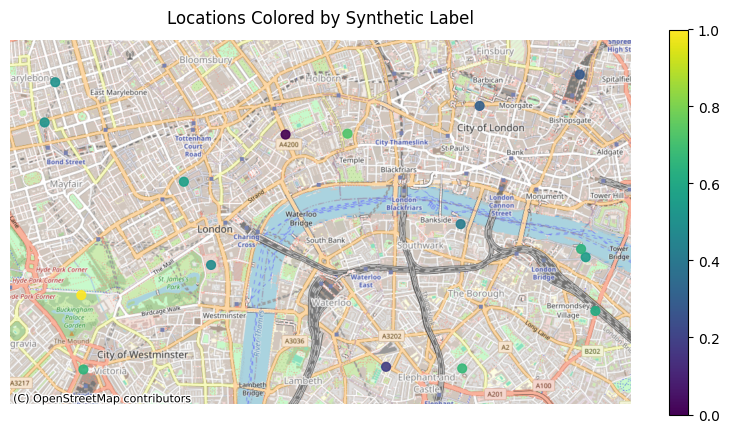

In [ ]:
def rbf_kernel(coords: np.ndarray, length_scale: float=0.01, variance: float=1.0) -> np.ndarray:
    """
    Squared-exponential (RBF) kernel on lat/lon coordinates.
    
    Parameters
    ----------
    coords : np.ndarray
        (n, 2) array of [lat, lon] coordinates.
    length_scale : float
        Length scale parameter for the RBF kernel.
    variance : float
        Variance parameter for the RBF kernel.

    Returns
    -------
    np.ndarray
        (n, n) RBF kernel matrix.
    """
    diffs = coords[:, None, :] - coords[None, :, :]
    dist2 = np.sum(diffs**2, axis=-1)
    return variance * np.exp(-0.5 * dist2 / (length_scale**2))


# Generate synthetic target variables
coords = gdf[['lat','lon']].to_numpy()
K = rbf_kernel(coords, length_scale=0.004, variance=1.0)
K = K + 1e-6 * np.eye(len(coords))
synthetic_field = rng.multivariate_normal(mean=np.zeros(len(coords)), cov=K)
syn_min, syn_max = synthetic_field.min(), synthetic_field.max()
synthetic_norm = (synthetic_field - syn_min) / (syn_max - syn_min + 1e-12)
gdf['synthetic_label'] = synthetic_norm
gdf.head()

# Plot
gdf_3857 = gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(10, 5))
gdf_3857.plot(
    ax=ax,
    column='synthetic_label',
    cmap='viridis',
    markersize=40,
    alpha=0.9,
    legend=True
)
buffer_m = 500  # meters
total_bounds = gdf_3857.total_bounds
xmin, ymin, xmax, ymax = total_bounds
xmin, ymin, xmax, ymax = xmin - buffer_m, ymin - buffer_m, xmax + buffer_m, ymax + buffer_m
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
cx.add_basemap(ax, crs=gdf_3857.crs, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("Locations Colored by Synthetic Label", pad=12)
plt.show()


## 7) Encode Locations with **UrbanFusion** (Multimodal Setting)

UrbanFusion is a **multimodal encoder** that can integrate several data modalities as input:  
- **Coordinates** (latitude/longitude)  
- **Street-view imagery (SV)**  
- **Remote sensing (RS)**  
- **Cartographic basemaps from OpenStreetMap (OSM)**  
- **Points of interest (POI)**  

The choice of input modalities is **flexible**, depending on data availability and the downstream application. Note that we set `precomputed_features=False` when initializing the model, which specifies that we are working with raw input modalities rather than features extracted from a backbone.



In [8]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create input tensors
coords_tensor = torch.tensor(gdf[['lat','lon']].to_numpy(), dtype=torch.float32, device=device)
sv_tensors = sv_tensors.to(device)  # SV tensor already created above
rs_tensor = rs_tensor.to(device)  # RS tensor already created above
osm_tensors = osm_tensors.to(device)  # OSM tensor already created above
poi_tensors = poi_tensors.to(device)  # POI tensor already created above

# Placeholders for other modalities (SV, RS, OSM, POI)
placeholder = torch.empty(coords_tensor.shape[0], device=device)

# List of all modalities, which are inputs to the model
inputs = [coords_tensor, sv_tensors, rs_tensor, osm_tensors, poi_tensors]

# Mask all but coordinates (indices: 0=coords, 1=SV, 2=RS, 3=OSM, 4=POI)
mask_indices = []

# Load pretrained UrbanFusion model from Hugging Face Hub
ckpt = hf_hub_download("DominikM198/UrbanFusion", "UrbanFusion/UrbanFusion.ckpt")
model = get_urbanfusion(ckpt, precomputed_features=False, device=device).eval()

# Use UrbanFusion model for encoding coordinates
with torch.no_grad():
    embeddings = model(inputs, mask_indices=mask_indices, return_representations=True).detach().cpu().numpy()

print("Embeddings shape:", embeddings.shape)

✅ Checkpoint loaded: C:\Users\domin\.cache\huggingface\hub\models--DominikM198--UrbanFusion\snapshots\23b77424ed36aa776cf3b0158ad9d19adccf7f1a\UrbanFusion\UrbanFusion.ckpt
✅ Weights loaded successfully.
Embeddings shape: (16, 768)


More modalities do not necessarily correlate with better downstream task performance. The relevance of each modality depends strongly on the specific task. Therefore, it is often sufficient to use only a subset of modalities—for example, street-view and satellite images—especially when applying the model to regions where UrbanFusion was not trained. In such areas, the coordinate encoder alone cannot produce semantically rich embeddings.

The following example demonstrates how to generate embeddings using only satellite and street-view images:


In [9]:
# List of all modalities, which are inputs to the model
inputs = [placeholder, sv_tensors, rs_tensor, placeholder, placeholder]

# Mask all but coordinates (indices: 0=coords, 1=SV, 2=RS, 3=OSM, 4=POI)
mask_indices = [0, 3, 4]

# Use UrbanFusion model for encoding coordinates
with torch.no_grad():
    embeddings = model(inputs, mask_indices=mask_indices, return_representations=True).detach().cpu().numpy()

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (16, 768)


In some situations, we may prefer not to process raw modalities directly but instead operate on features already extracted by the modality-specific encoders. This can be useful during training to reduce GPU compute and memory usage, or when sufficient GPU memory is not available. In such cases, backbones can be loaded to the GPU sequentially for feature extraction, and the compressed features can be stored on disk to save space.   

The following example demonstrates how to perform feature extraction for each modality separately and how to initialize UrbanFusion to operate on precomputed features by setting `precomputed_features=True`.


In [10]:
# Extract features for each modality
sv_features = model.encoders[1].forward_features(sv_tensors)
rs_features = model.encoders[2].forward_features(rs_tensor)
osm_features = model.encoders[3].forward_features(osm_tensors)
poi_features = model.encoders[4].forward_features(poi_tensors)

# Print shapes of extracted features
print("Shape of SV features:", sv_features.shape)
print("Shape of RS features:", rs_features.shape)
print("Shape of OSM features:", osm_features.shape)
print("Shape of POI features:", poi_features.shape)

# List of all modalities, which are inputs to the model
inputs = [coords_tensor, sv_features, rs_features, osm_features, poi_features]

# Mask all but coordinates (indices: 0=coords, 1=SV, 2=RS, 3=OSM, 4=POI)
mask_indices = []

# Load pretrained UrbanFusion model from Hugging Face Hub
ckpt = hf_hub_download("DominikM198/UrbanFusion", "UrbanFusion/UrbanFusion.ckpt")
model = get_urbanfusion(ckpt, precomputed_features=True, device=device).eval()

# Use UrbanFusion model for encoding coordinates
with torch.no_grad():
    embeddings = model(inputs, mask_indices=mask_indices, return_representations=True).detach().cpu().numpy()

print("Embeddings shape:", embeddings.shape)


Shape of SV features: torch.Size([16, 768])
Shape of RS features: torch.Size([16, 384])
Shape of OSM features: torch.Size([16, 2304])
Shape of POI features: torch.Size([16, 384])
✅ Checkpoint loaded: C:\Users\domin\.cache\huggingface\hub\models--DominikM198--UrbanFusion\snapshots\23b77424ed36aa776cf3b0158ad9d19adccf7f1a\UrbanFusion\UrbanFusion.ckpt
✅ Weights loaded successfully.
Embeddings shape: (16, 768)


## 8) Qualitative Analysis of UrbanFusion Representations

The code below reduces the embeddings to three principal components using PCA, scales them to the [0, 1] range, and visualizes the results as RGB colors on a map of London.


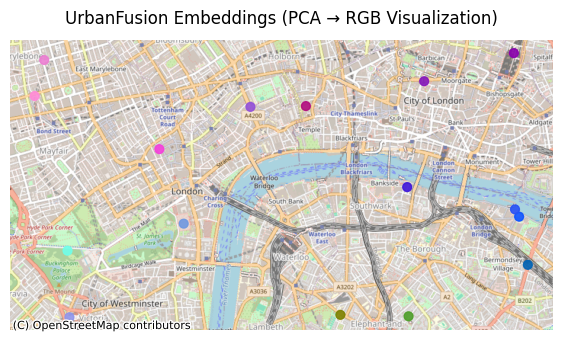

In [11]:
# PCA to 3 components
Z = PCA(n_components=3, random_state=42).fit_transform(embeddings)

# Normalize each comp to 0..1
def to_01(x): 
    a, b = np.percentile(x, [1, 99])
    return np.clip((x - a) / (b - a), 0, 1)

# Assign RGB colors to the three PCA components
rgb = np.stack([to_01(Z[:,0]), to_01(Z[:,1]), to_01(Z[:,2])], axis=1)

# Add colors to gdf and project for basemap
gdf_plot = gdf.to_crs(epsg=3857).copy()
gdf_plot["rgb"] = list(map(tuple, rgb))

# Plot
fig, ax = plt.subplots(figsize=(7,7))
gdf_plot.plot(ax=ax, color=gdf_plot["rgb"], markersize=40, alpha=0.9)
cx.add_basemap(ax, crs=gdf_plot.crs, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("UrbanFusion Embeddings (PCA → RGB Visualization)", pad=12)
plt.show()


## 9) Train and Apply a Downstream Learner for Spatial Regression

Once we have generated location embeddings with UrbanFusion, we can use them as input features for a downstream model (e.g., linear regression, random forest, or an MLP) to predict a target variable at each location.  

The example below demonstrates how to use the UrbanFusion representations to train a **ridge regression model** on the synthetic labels created earlier.


In [12]:
# X: UrbanFusion representations (input features)
X = np.asarray(embeddings)
# y: synthetic labels from earlier step (target variable)
y = gdf['synthetic_label'].to_numpy()

# Train/test split
idx_train, idx_test = train_test_split(np.arange(len(X)), test_size=0.5, random_state=42, shuffle=True)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

# Standardize features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Tune alpha via Leave-One-Out CV on the training set
alphas = np.logspace(-4, 4, 25)
best_alpha = RidgeCV(alphas=alphas, cv=LeaveOneOut(), scoring="neg_mean_squared_error").fit(X_train_s, y_train).alpha_

# Train final model
model = Ridge(alpha=best_alpha).fit(X_train_s, y_train)

# Apply model to test set (or new data if model is deployed)
y_pred = model.predict(X_test_s)
rmse = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

print(f"Best alpha: {best_alpha:.6g}")
print(f"Test RMSE: {rmse:.4f} | MAE: {mae:.4f}")


Best alpha: 0.0001
Test RMSE: 0.0938 | MAE: 0.2476


## 10) Wrap-Up and Next Steps

In this tutorial, we:

- Sampled **16 random locations** in central London.  
- Created a **synthetic spatially autocorrelated label** to mimic a real-world target variable.  
- Generated **multimodal embeddings** with the UrbanFusion model, exploring both raw and precomputed modalities as inputs.  
- Produced a **qualitative visualization** of the embeddings using PCA and RGB mapping.  
- Applied these embeddings in a **downstream regression task** (ridge regression) to predict the synthetic labels.  

This tutorial demonstrated how UrbanFusion representations can support spatial learning tasks using flexible combinations of modalities, tailored to the requirements of the downstream task and the availability of data.
